In [2]:
import pandas as pd

In [4]:
data = pd.read_csv("Amazon_Unlocked_Mobile.csv.csv")

In [5]:
data.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [6]:
data.shape

(413840, 6)

In [7]:
data["Brand Name"].value_counts().head(10)

Brand Name
Samsung       65747
BLU           63248
Apple         58186
LG            22417
BlackBerry    16872
Nokia         16806
Motorola      13417
HTC           12724
CNPGD         12613
OtterBox       7989
Name: count, dtype: int64

In [8]:
# مسح أي صف فيه مراجعة فاضية
data.dropna(subset=['Reviews'], inplace=True)

# التأكد إن السعر رقمي (Numeric) عشان نعرف نحسبه
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')

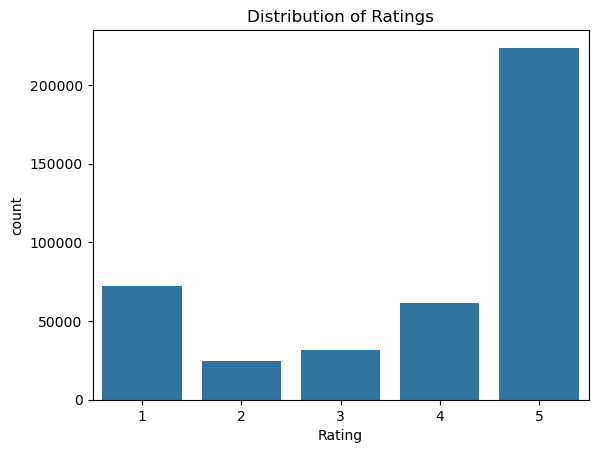

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=data, x='Rating')
plt.title('Distribution of Ratings')
plt.show()

Sentiment
Positive    284948
Negative     97059
Neutral      31763
Name: count, dtype: int64


C:\Users\amr\AppData\Local\Temp\ipykernel_18284\2717272818.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Sentiment', palette='viridis')


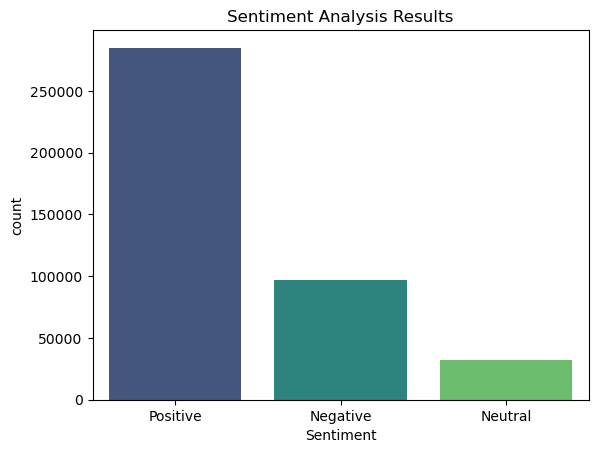

In [10]:
# دالة لتصنيف المراجعة بناءً على التقييم (Rating)
def sentiment_rating(rating):
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return "Neutral"

# تطبيق الدالة على عمود جديد اسمه Sentiment
data['Sentiment'] = data['Rating'].apply(sentiment_rating)

# نشوف كام مراجعة إيجابية وكام سلبية
print(data['Sentiment'].value_counts())

# رسم بياني للمشاعر (Sentiment Distribution)
sns.countplot(data=data, x='Sentiment', palette='viridis')
plt.title('Sentiment Analysis Results')
plt.show()

In [11]:
# عرض أول 5 مراجعات سلبية (Negative)
data[data['Sentiment'] == 'Negative']['Reviews'].head()

5     I already had a phone with problems... I know ...
6     The charging port was loose. I got that solder...
7     Phone looks good but wouldn't stay charged, ha...
13    I'm really disappointed about my phone and ser...
15    Had this phone before and loved it but was not...
Name: Reviews, dtype: str

In [12]:
# حساب متوسط السعر والتقييم لكل ماركة
brand_analysis = data.groupby('Brand Name').agg({'Price': 'mean', 'Rating': 'mean', 'Reviews': 'count'}).sort_values(by='Reviews', ascending=False)

# عرض أول 10 ماركات من حيث عدد المراجعات
print(brand_analysis.head(10))

                 Price    Rating  Reviews
Brand Name                               
Samsung     291.773619  3.962693    65725
BLU         245.409267  3.792224    63246
Apple       306.301936  3.924543    58179
LG          207.833874  3.841455    22410
BlackBerry   89.799537  3.741465    16872
Nokia       154.165901  3.819458    16805
Motorola    151.396294  3.812584    13414
HTC         161.219036  3.465420    12724
CNPGD        52.007997  3.106002    12613
OtterBox     18.999176  4.383623     7987


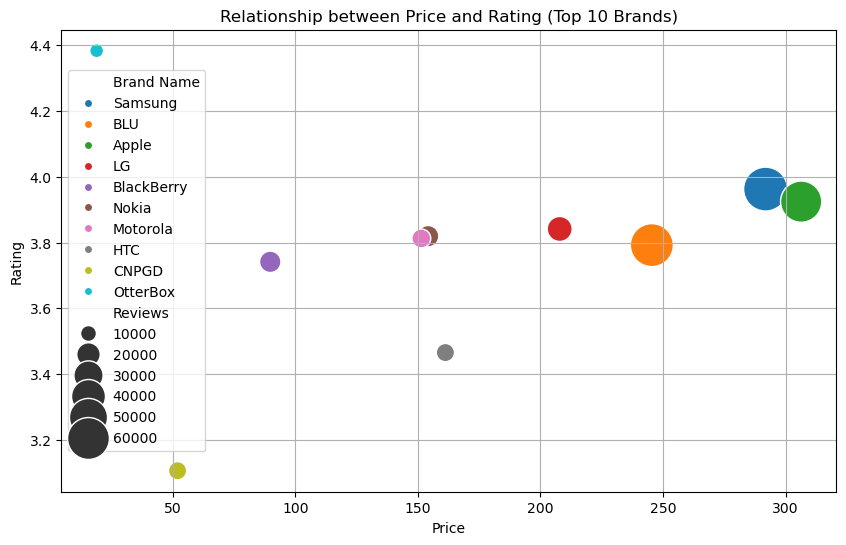

In [13]:
# رسم علاقة متوسط السعر بمتوسط التقييم لأول 10 ماركات
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_analysis.head(10), x='Price', y='Rating', size='Reviews', hue='Brand Name', sizes=(100, 1000))
plt.title('Relationship between Price and Rating (Top 10 Brands)')
plt.grid(True)
plt.show()

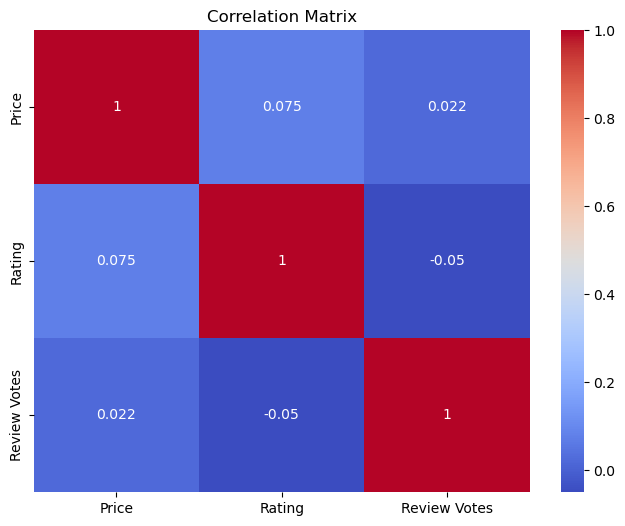

In [14]:
# رسم خريطة الارتباط بين الأرقام
plt.figure(figsize=(8,6))
sns.heatmap(data[['Price', 'Rating', 'Review Votes']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [17]:
!pip install wordcloud

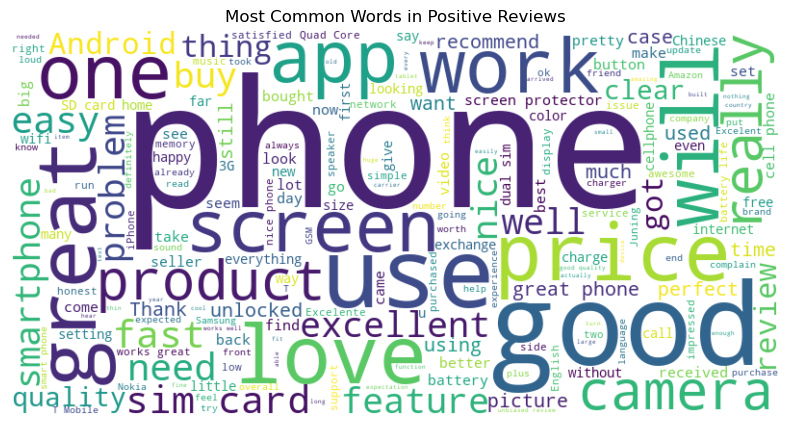

In [18]:
from wordcloud import WordCloud

# تجميع كل المراجعات الإيجابية في نص واحد كبير
pos_reviews = " ".join(review for review in data[data['Sentiment'] == 'Positive']['Reviews'].dropna().head(1000))

# إنشاء سحابة الكلمات
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(pos_reviews)

# عرض الصورة
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews')
plt.show()

In [19]:
# تصفية الماركات اللي واخدة تقييم أعلى من 4 وسعرها أقل من متوسط السوق
good_value = brand_analysis[(brand_analysis['Rating'] > 4) & (brand_analysis['Price'] < data['Price'].mean())]
print("Best Value Brands (High Rating & Low Price):")
print(good_value)

Best Value Brands (High Rating & Low Price):
                  Price    Rating  Reviews
Brand Name                                
OtterBox      18.999176  4.383623     7987
Alcatel      150.536103  4.045969     1414
Jitterbug     93.694462  4.102431      576
HUAWEI       162.902523  4.179673      551
SAMSUNG      216.670277  4.253235      541
...                 ...       ...      ...
ssiony        65.990000  5.000000        1
AeroAntenna  225.000000  5.000000        1
AT&T           3.990000  5.000000        1
RomaCostume   23.400000  5.000000        1
TracFone      24.990000  5.000000        1

[76 rows x 3 columns]


In [22]:
# حفظ قائمة أفضل الماركات من حيث القيمة في ملف إكسل
good_value.to_excel('Best_Value_Mobile_Brands.xlsx')